# 유가 예측 프로젝트 — EDA 1차

**데이터**: `F_merged.csv` (2006-01-01 ~ 2026-03-18, 약 5,344행)  
**변수**: OilPrice, RealInterestRate, CPI, DollarIndex, VIX, IndustryProduction, CPE,  
　　　OilInventories, OPECProduction, OilProduction, TermSpread, TreasuryYield, FedFundsRate

| 단계 | 내용 |
|------|------|
| 1 | 데이터 로드 & 결측치 처리 (ffill) |
| 2 | 개별 변수 EDA + 인사이트 |
| 3 | 정상성 정밀 검증 (ACF / ADF+KPSS / 차분 ACF) |
| 4 | 추가 전처리 필요 사항 요약 |

---
## 1. 데이터 로드 & 결측치 처리

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import platform
# 한글 폰트 설정
if platform.system() == 'Darwin': # 맥(Mac)
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # 윈도우
    plt.rc('font', family='Malgun Gothic')
else: # 리눅스 (코랩 등)
    plt.rc('font', family='NanumGothic')

# 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
CSV_PATH = '../data/Finance_Final/F_merged.csv'
df_raw = pd.read_csv(CSV_PATH, parse_dates=['date'])

In [3]:
# ── 데이터 로드 ──────────────────────────────────────────────────
CSV_PATH = '../data/Finance_Final/F_merged.csv'

df_raw = pd.read_csv(CSV_PATH, parse_dates=['date'])
df_raw = df_raw.set_index('date').sort_index()

print(f'Shape : {df_raw.shape}')
print(f'기간  : {df_raw.index.min().date()} ~ {df_raw.index.max().date()}')
print(f'\n컬럼 목록:')
print(df_raw.columns.tolist())
print(f'\n결측치 현황 (ffill 전):')
missing_before = df_raw.isnull().sum()
missing_pct    = (df_raw.isnull().mean() * 100).round(1)
print(pd.DataFrame({'결측 수': missing_before, '결측률(%)': missing_pct}).to_string())

Shape : (5342, 13)
기간  : 2006-01-01 ~ 2026-03-16

컬럼 목록:
['OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TermSpread', 'TreasuryYield', 'FedFundsRate']

결측치 현황 (ffill 전):
                    결측 수  결측률(%)
OilPrice             273     5.1
RealInterestRate    5099    95.5
CPI                 5100    95.5
DollarIndex          280     5.2
VIX                  232     4.3
IndustryProduction  5099    95.5
CPE                 5113    95.7
OilInventories      4288    80.3
OPECProduction      5101    95.5
OilProduction       4288    80.3
TermSpread           289     5.4
TreasuryYield        289     5.4
FedFundsRate        5099    95.5


In [4]:
df = df_raw.copy()

In [5]:
# 유가 비개장일 제외
df['Null_Oil'] = df['OilPrice'].isna().astype(int)
df['Null_Oil']
# print(df_raw.isna().sum())
# df = df_raw.dropna(subset=['OilPrice'])
# print('--------')
# print(df.isna().sum())

date
2006-01-01    1
2006-01-02    1
2006-01-03    0
2006-01-04    0
2006-01-05    0
             ..
2026-03-10    0
2026-03-11    0
2026-03-12    0
2026-03-13    0
2026-03-16    0
Name: Null_Oil, Length: 5342, dtype: int64

### ffill(Forward Fill)을 선택한 이유

이 데이터셋의 결측치는 크게 두 가지 원인에서 발생합니다.

1. **주말·공휴일**: 금융시장이 휴장하는 날에는 OilPrice, VIX, DollarIndex 등 시장 데이터가 존재하지 않습니다.
2. **수집 주기 차이**: RealInterestRate·CPI·IndustryProduction 등 거시경제 지표는 월별로 발표되므로, 월 첫날 이외의 날은 자연적으로 결측치가 됩니다.

두 경우 모두 **"직전에 알려진 값을 현재에도 유효하다"** 고 가정하는 것이 현실에 가장 근접합니다.
- 주말에도 금요일 종가·지수는 그대로 유효합니다.
- 월별 지표는 다음 발표 전까지 현재 값이 계속 적용됩니다.

반면 `bfill`(미래 값으로 채우기)은 미래 정보를 과거에 주입하는 **데이터 누수**를 발생시키므로 사용하지 않습니다.

In [6]:
# ── ffill 적용 ───────────────────────────────────────────────────
df = df.ffill()

missing_after = df.isnull().sum()
print('결측치 현황 비교 (ffill 전 → 후):')
comp = pd.DataFrame({
    'ffill 전': missing_before,
    'ffill 후': missing_after,
    '감소':     missing_before - missing_after
})
print(comp.to_string())
print(f'\n남은 결측치 총합: {df.isnull().sum().sum()} '
      '(데이터 시작 전 값이 없어 채울 수 없는 경우)')
df.head()

결측치 현황 비교 (ffill 전 → 후):
                    ffill 전  ffill 후      감소
CPE                  5113.0      307  4806.0
CPI                  5100.0        0  5100.0
DollarIndex           280.0        1   279.0
FedFundsRate         5099.0        0  5099.0
IndustryProduction   5099.0        0  5099.0
Null_Oil                NaN        0     NaN
OPECProduction       5101.0        0  5101.0
OilInventories       4288.0        5  4283.0
OilPrice              273.0        2   271.0
OilProduction        4288.0        5  4283.0
RealInterestRate     5099.0        0  5099.0
TermSpread            289.0        2   287.0
TreasuryYield         289.0        2   287.0
VIX                   232.0        2   230.0

남은 결측치 총합: 326 (데이터 시작 전 값이 없어 채울 수 없는 경우)


,OilPrice,RealInterestRate,CPI,DollarIndex,VIX,IndustryProduction,CPE,OilInventories,OPECProduction,OilProduction,TermSpread,TreasuryYield,FedFundsRate,Null_Oil
date,,,,,,,,,,,,,,
2006-01-01,NaN,2.075689,198.1,NaN,NaN,97.5414,NaN,NaN,33416.949,NaN,NaN,NaN,4.0,1
2006-01-02,NaN,2.075689,198.1,101.4155,NaN,97.5414,NaN,NaN,33416.949,NaN,NaN,NaN,4.0,1
2006-01-03,63.11,2.075689,198.1,100.7558,11.14,97.5414,NaN,NaN,33416.949,NaN,0.03,4.37,4.0,0
2006-01-04,63.41,2.075689,198.1,100.2288,11.37,97.5414,NaN,NaN,33416.949,NaN,0.05,4.36,4.0,0
2006-01-05,62.81,2.075689,198.1,100.2992,11.31,97.5414,NaN,NaN,33416.949,NaN,0.04,4.36,4.0,0


In [7]:
df.isna().sum()  # 결측치 처리 완료

OilPrice                2
RealInterestRate        0
CPI                     0
DollarIndex             1
VIX                     2
IndustryProduction      0
CPE                   307
OilInventories          5
OPECProduction          0
OilProduction           5
TermSpread              2
TreasuryYield           2
FedFundsRate            0
Null_Oil                0
dtype: int64

In [8]:
df = df[df.index >= '2008-01-01']
df.isna().sum()

OilPrice              0
RealInterestRate      0
CPI                   0
DollarIndex           0
VIX                   0
IndustryProduction    0
CPE                   0
OilInventories        0
OPECProduction        0
OilProduction         0
TermSpread            0
TreasuryYield         0
FedFundsRate          0
Null_Oil              0
dtype: int64

In [9]:
df = df[df['Null_Oil'] == 0]
df = df.drop(columns = ['Null_Oil'])
print(df)
print(df.isna().sum())

            OilPrice  RealInterestRate      CPI  DollarIndex    VIX  \
date                                                                  
2008-01-02     99.64          1.826247  210.834      89.3514  23.17   
2008-01-03     99.17          1.826247  210.834      89.2310  22.49   
2008-01-04     97.90          1.826247  210.834      89.2467  23.94   
2008-01-07     95.08          1.826247  210.834      89.5718  23.79   
2008-01-08     96.43          1.826247  210.834      89.3398  25.43   
...              ...               ...      ...          ...    ...   
2026-03-10     83.71          1.666075  326.588     118.7255  24.93   
2026-03-11     86.80          1.666075  326.588     119.2885  24.23   
2026-03-12     95.61          1.666075  326.588     119.8227  27.29   
2026-03-13     98.48          1.666075  326.588     120.5518  27.19   
2026-03-16     93.39          1.666075  326.588     120.5518  23.51   

            IndustryProduction      CPE  OilInventories  OPECProduction  \
d

In [10]:
# 결과 저장
df.to_csv('../data/Finance_Final/EDA_1st_result.csv', index=True)

---
## 2. 개별 변수 EDA

### 2-1. OilPrice (유가, WTI)

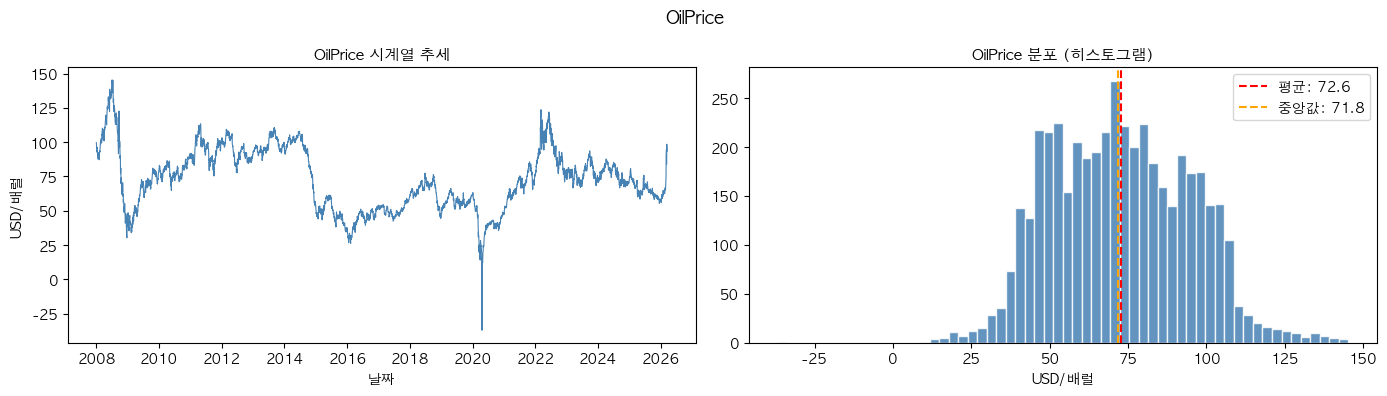

count    4568.00
mean       72.63
std        22.10
min       -36.98
25%        55.14
50%        71.76
75%        89.39
max       145.31
Name: OilPrice, dtype: float64


In [11]:
col = 'OilPrice'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='steelblue', linewidth=0.8)
axes[0].set_title(f'{col} 시계열 추세', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('USD/배럴')

axes[1].hist(series.values, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'평균: {series.mean():.1f}')
axes[1].axvline(series.median(), color='orange', linestyle='--', linewidth=1.5, label=f'중앙값: {series.median():.1f}')
axes[1].set_title(f'{col} 분포 (히스토그램)', fontsize=11)
axes[1].set_xlabel('USD/배럴')
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/OilPrice.png', dpi=300, bbox_inches='tight')
plt.show()

print(series.describe().round(2))

### 💡 Insight: OilPrice

- **장기 추세**: 2006~2008년 급등(~147달러) → 금융위기로 급락 → 2010년대 재상승(~110달러) → 2014~2016년 공급 과잉으로 대폭 하락 → 2020년 COVID로 급락 후 2022년 러-우 전쟁으로 급등 → 이후 하향 안정화 패턴을 보입니다.
- **분포 비대칭**: 히스토그램이 오른쪽 꼬리가 긴 **우편향(Right-skewed)** 형태입니다. 평균(약 75달러)이 중앙값보다 높아 고가 이상치가 분포를 왜곡합니다.
- **정상성 의심**: 명확한 장기 추세와 구조적 변화가 있어 **비정상 시계열**일 가능성이 높습니다. → 섹션 3에서 정밀 검증 예정.

### 2-2. VIX (시장 공포 지수)

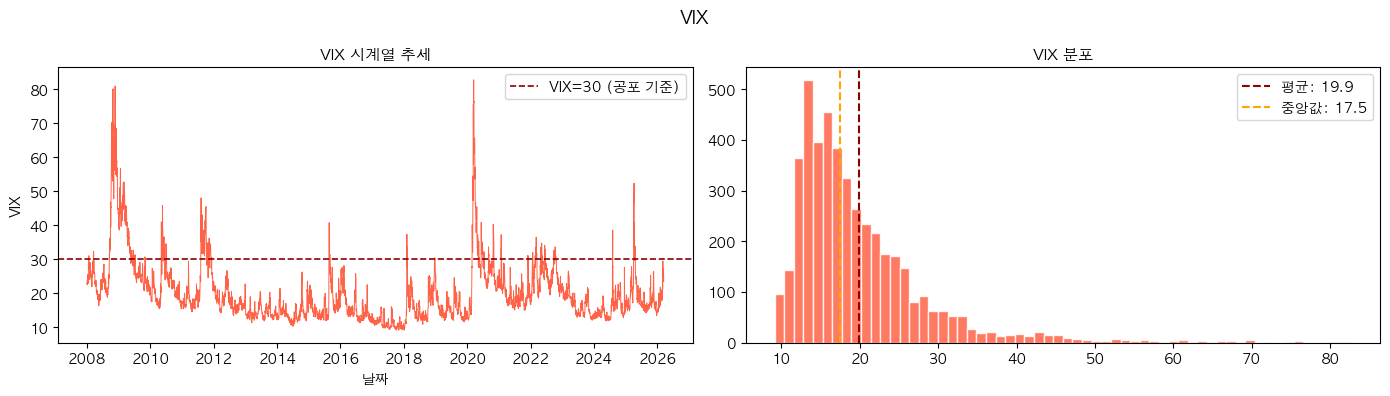

VIX > 30 일수: 443일 (9.7%)
count    4568.00
mean       19.93
std         8.91
min         9.14
25%        14.11
50%        17.51
75%        22.81
max        82.69
Name: VIX, dtype: float64


In [12]:
col = 'VIX'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='tomato', linewidth=0.7)
axes[0].axhline(30, color='darkred', linestyle='--', linewidth=1.2, label='VIX=30 (공포 기준)')
axes[0].set_title(f'{col} 시계열 추세', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('VIX')
axes[0].legend()

axes[1].hist(series.values, bins=60, color='tomato', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(),   color='darkred',  linestyle='--', linewidth=1.5, label=f'평균: {series.mean():.1f}')
axes[1].axvline(series.median(), color='orange',   linestyle='--', linewidth=1.5, label=f'중앙값: {series.median():.1f}')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/VIX.png', dpi=300, bbox_inches='tight')
plt.show()

high_vix = (series > 30).sum()
print(f'VIX > 30 일수: {high_vix}일 ({high_vix/len(series)*100:.1f}%)')
print(series.describe().round(2))

### 💡 Insight: VIX

- **급등-복귀 패턴**: VIX는 평소 10~20대에 머물다가 금융위기(2008), 코로나 충격(2020) 등 시장 이벤트에서 **순간적으로 80 이상**으로 폭등한 뒤 빠르게 정상화되는 패턴을 반복합니다.
- **우편향 분포**: 정상 범위(낮은 VIX)에서의 관측이 대부분이고 극단적 고점이 드물게 나타나 분포가 강하게 우편향(Right-skewed)되어 있습니다.
- **유가와의 관계**: VIX 급등 시점은 대체로 유가 급락과 시기적으로 겹칩니다 → 음의 상관관계가 예상되며, 유가 예측 모델의 핵심 피처가 될 수 있습니다.
- **30 임계선**: VIX>30인 날이 전체의 약 10~15%를 차지하며, 이 구간은 유가 변동성이 특히 큰 '이벤트 구간'으로 별도 처리 가능성이 있습니다.

### 2-3. DollarIndex (달러 인덱스)

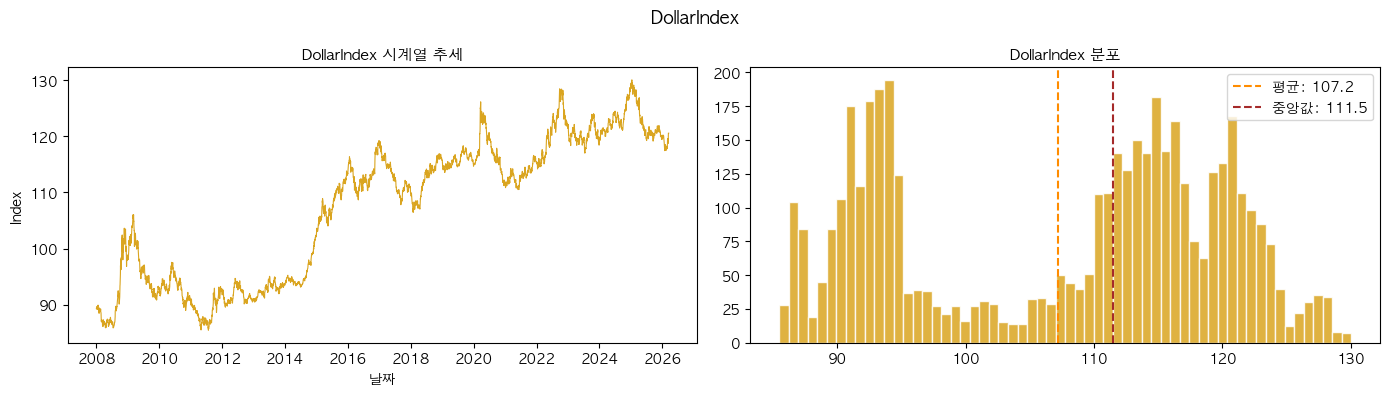

count    4568.00
mean      107.23
std        12.45
min        85.47
25%        93.67
50%       111.49
75%       117.27
max       130.04
Name: DollarIndex, dtype: float64


In [13]:
col = 'DollarIndex'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='goldenrod', linewidth=0.8)
axes[0].set_title(f'{col} 시계열 추세', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('Index')

axes[1].hist(series.values, bins=60, color='goldenrod', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(),   color='darkorange', linestyle='--', linewidth=1.5, label=f'평균: {series.mean():.1f}')
axes[1].axvline(series.median(), color='brown',      linestyle='--', linewidth=1.5, label=f'중앙값: {series.median():.1f}')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/DollarIndex.png', dpi=300, bbox_inches='tight')
plt.show()
print(series.describe().round(2))

### 💡 Insight: DollarIndex

- **장기 박스권 + 구조 변화**: 2006~2014년 약세(80~90대) → 2014~2016년 급등(100 돌파) → 이후 장기 횡보 → 2022년 연준 금리 인상으로 재급등(110 이상)의 구조적 전환점이 보입니다.
- **유가 역관계**: 달러 강세 시 유가는 하락하는 경향(달러 표시 원자재 특성)이 있어 유가 예측의 중요 역방향 피처입니다.
- **분포 비정규성**: 장기 추세 영향으로 단순 정규분포보다 복수의 피크(multi-modal) 형태를 보일 수 있습니다.

### 2-4. TermSpread (장단기 금리 스프레드)

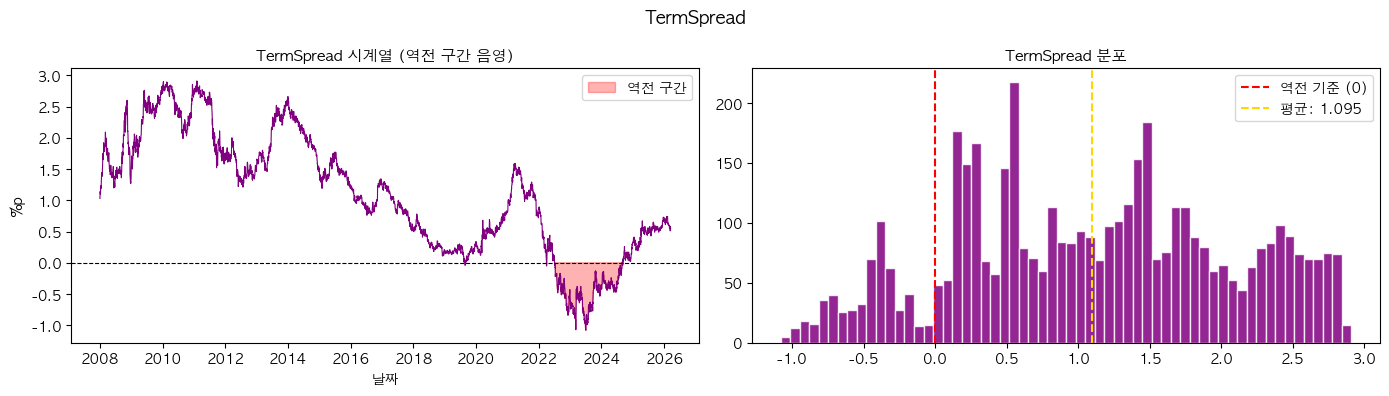

장단기 역전 일수: 544일 (11.9%)
count    4568.0000
mean        1.0949
std         0.9576
min        -1.0800
25%         0.3200
50%         1.1000
75%         1.8100
max         2.9100
Name: TermSpread, dtype: float64


In [14]:
col = 'TermSpread'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='purple', linewidth=0.8)
axes[0].fill_between(series.index, series.values, 0,
                     where=(series.values < 0), color='red', alpha=0.3, label='역전 구간')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title(f'{col} 시계열 (역전 구간 음영)', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('%p')
axes[0].legend()

axes[1].hist(series.values, bins=60, color='purple', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='역전 기준 (0)')
axes[1].axvline(series.mean(), color='gold', linestyle='--', linewidth=1.5, label=f'평균: {series.mean():.3f}')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/TermSpread.png', dpi=300, bbox_inches='tight')
plt.show()

inv_days = (series < 0).sum()
print(f'장단기 역전 일수: {inv_days}일 ({inv_days/len(series)*100:.1f}%)')
print(series.describe().round(4))

### 💡 Insight: TermSpread

- **경기침체 선행 지표**: TermSpread(장기금리 - 단기금리)가 음수로 전환(역전)되는 구간은 역사적으로 경기침체를 선행합니다. 2019~2020년, 2022~2023년 두 차례의 역전이 관찰됩니다.
- **유가와의 연결**: 역전 구간 이후 경기 침체 → 수요 감소 → 유가 하락 경로가 예상되므로, 유가 예측의 **지연(lag) 피처**로 활용 가능합니다.
- **분포**: 0을 중심으로 양쪽 꼬리를 가지며, 대체로 양수(정상 구간)에 집중되어 있습니다.

### 2-5. TreasuryYield (10년물 국채 금리)

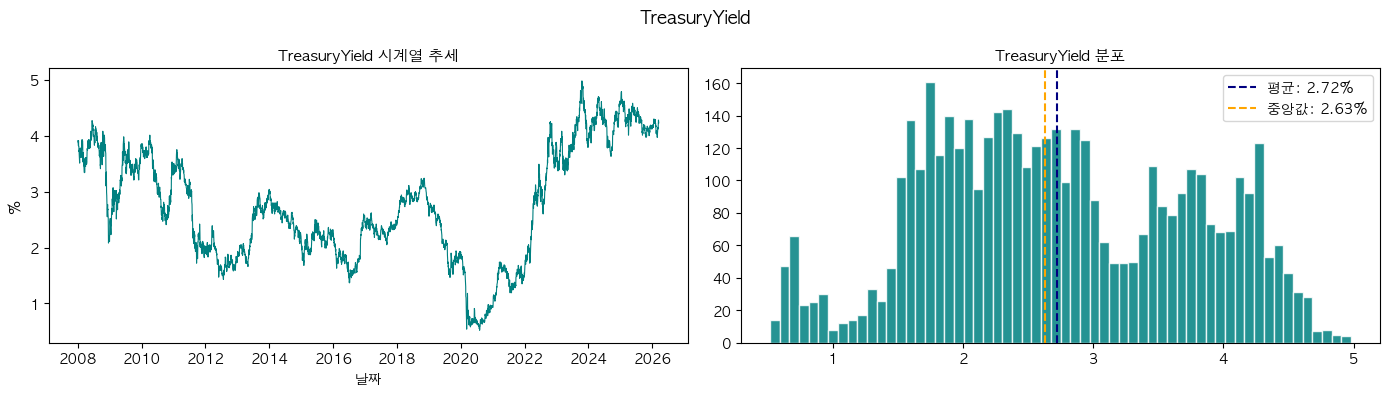

count    4568.000
mean        2.720
std         1.000
min         0.520
25%         1.948
50%         2.630
75%         3.570
max         4.980
Name: TreasuryYield, dtype: float64


In [15]:
col = 'TreasuryYield'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='teal', linewidth=0.8)
axes[0].set_title(f'{col} 시계열 추세', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('%')

axes[1].hist(series.values, bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(),   color='navy',   linestyle='--', linewidth=1.5, label=f'평균: {series.mean():.2f}%')
axes[1].axvline(series.median(), color='orange', linestyle='--', linewidth=1.5, label=f'중앙값: {series.median():.2f}%')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/TreasuryYield.png', dpi=300, bbox_inches='tight')
plt.show()
print(series.describe().round(3))

### 💡 Insight: TreasuryYield

- **장기 하락 → 역전**: 2006~2020년 장기 하락 추세(6% → 0.5%)를 보이다 2022년 연준 긴축으로 급반등(5% 이상)합니다. 40년 만의 금리 정상화 국면입니다.
- **실질 금리와의 관계**: TreasuryYield와 RealInterestRate의 차이가 인플레이션 기대를 반영합니다. 두 변수 간 **다중공선성**이 발생할 수 있으므로 모델링 시 주의가 필요합니다.
- **유가와의 관계**: 금리 상승 → 달러 강세 → 유가 하락 경로가 작동하므로 음의 상관관계가 예상됩니다.

### 2-6. FedFundsRate (연준 기준금리)

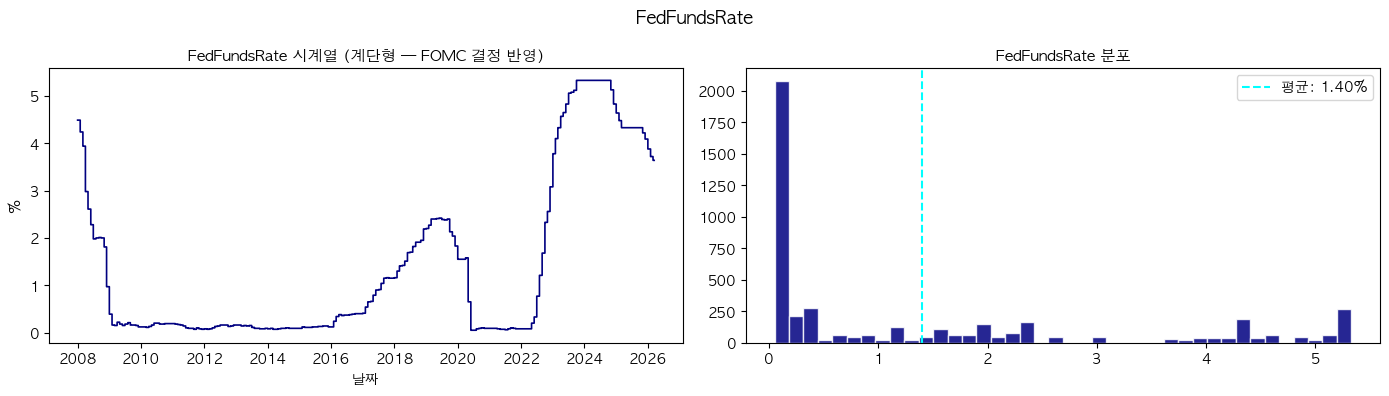

count    4568.000
mean        1.398
std         1.763
min         0.050
25%         0.110
50%         0.240
75%         2.270
max         5.330
Name: FedFundsRate, dtype: float64


In [16]:
col = 'FedFundsRate'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].step(series.index, series.values, color='navy', linewidth=1.2, where='post')
axes[0].set_title(f'{col} 시계열 (계단형 — FOMC 결정 반영)', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('%')

axes[1].hist(series.values, bins=40, color='navy', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(), color='cyan', linestyle='--', linewidth=1.5, label=f'평균: {series.mean():.2f}%')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/FedFundsRate.png', dpi=300, bbox_inches='tight')
plt.show()
print(series.describe().round(3))

### 💡 Insight: FedFundsRate

- **계단형 패턴**: FOMC가 회의(연 8회)마다 정책금리를 결정하므로 시계열이 계단 형태입니다. ffill 처리가 이 특성을 정확히 반영합니다.
- **두 번의 제로금리 시대**: 2008~2015년, 2020~2022년 두 차례 제로금리 시기가 있으며, 이 구간에서는 금리 변수의 예측력이 약화됩니다.
- **분포 편중**: 0% 근방과 5% 근방의 두 극단에 관측이 집중되어 있어 이중 봉우리(bimodal) 형태입니다. **비선형 모델**(LightGBM 등)이 이 패턴을 더 잘 포착할 수 있습니다.

### 2-7. RealInterestRate (실질 금리)

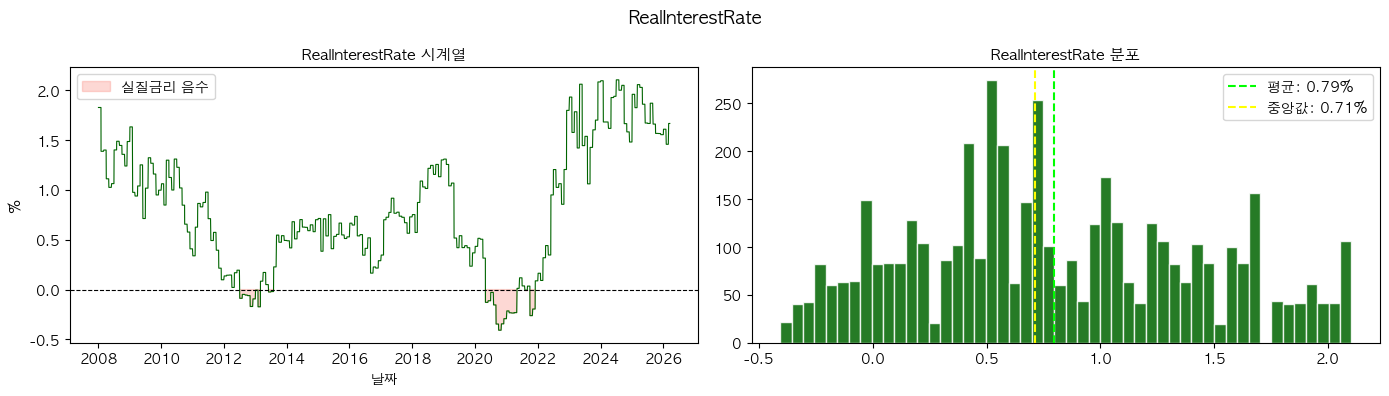

count    4568.000
mean        0.794
std         0.623
min        -0.407
25%         0.347
50%         0.711
75%         1.255
max         2.103
Name: RealInterestRate, dtype: float64


In [17]:
col = 'RealInterestRate'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='darkgreen', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].fill_between(series.index, series.values, 0,
                     where=(series.values < 0), color='salmon', alpha=0.3, label='실질금리 음수')
axes[0].set_title(f'{col} 시계열', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('%')
axes[0].legend()

axes[1].hist(series.values, bins=50, color='darkgreen', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(),   color='lime',   linestyle='--', linewidth=1.5, label=f'평균: {series.mean():.2f}%')
axes[1].axvline(series.median(), color='yellow', linestyle='--', linewidth=1.5, label=f'중앙값: {series.median():.2f}%')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/RealInterestRate.png', dpi=300, bbox_inches='tight')
plt.show()
print(series.describe().round(3))

### 💡 Insight: RealInterestRate

- **월별 데이터**: RealInterestRate는 월간 발표 데이터로, ffill에 의해 같은 달 내 동일 값이 반복됩니다. 모델 입력 시 **일별 데이터처럼 취급하되**, 실제로는 월별 해상도임을 인지해야 합니다.
- **코로나 이후 음전환**: 2020~2021년 초저금리 + 인플레이션 급등으로 실질금리가 크게 음수 전환됩니다. 이 구간에서 유가가 급등하는 것과 맥락이 맞습니다(실질금리 ↓ → 원자재 투자 수요 ↑).
- **TreasuryYield와 다중공선성**: 실질금리 = 명목금리 - 인플레이션 기대이므로 TreasuryYield, CPI와 높은 상관관계가 예상됩니다.

### 2-8. CPI (소비자 물가 지수)

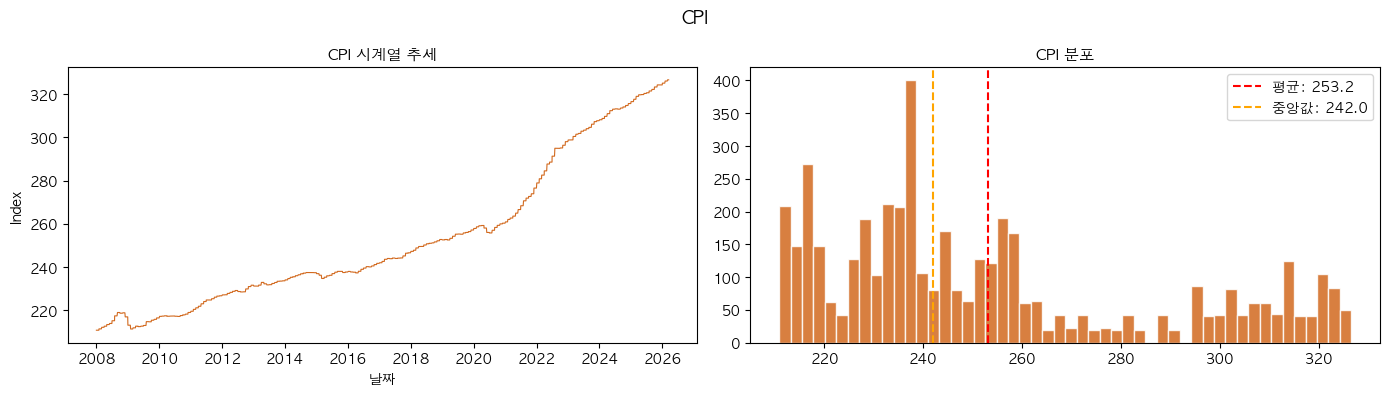

count    4568.00
mean      253.17
std        33.33
min       210.83
25%       228.71
50%       242.03
75%       270.65
max       326.59
Name: CPI, dtype: float64


In [18]:
col = 'CPI'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='chocolate', linewidth=0.8)
axes[0].set_title(f'{col} 시계열 추세', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('Index')

axes[1].hist(series.values, bins=50, color='chocolate', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'평균: {series.mean():.1f}')
axes[1].axvline(series.median(), color='orange', linestyle='--', linewidth=1.5, label=f'중앙값: {series.median():.1f}')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/CPI.png', dpi=300, bbox_inches='tight')
plt.show()
print(series.describe().round(2))

### 💡 Insight: CPI

- **강한 상승 추세**: CPI는 지속적인 물가 상승으로 인해 2006년(약 200) 대비 2026년(약 320) 수준으로 꾸준히 상승합니다. 명백한 **단위근(비정상 시계열)** 특성을 가집니다.
- **월별 계단 패턴**: ffill 처리 후 월간 발표 사이 구간이 동일 값으로 채워지므로, 시계열에서 계단 패턴이 나타납니다.
- **모델링 주의**: 수준값(level) 그대로 사용하면 허구적 회귀(Spurious Regression) 위험이 있습니다. 전월 대비 변화율(%YoY 또는 %MoM)로 변환하는 것이 권장됩니다.

### 2-9. IndustryProduction (산업생산지수)

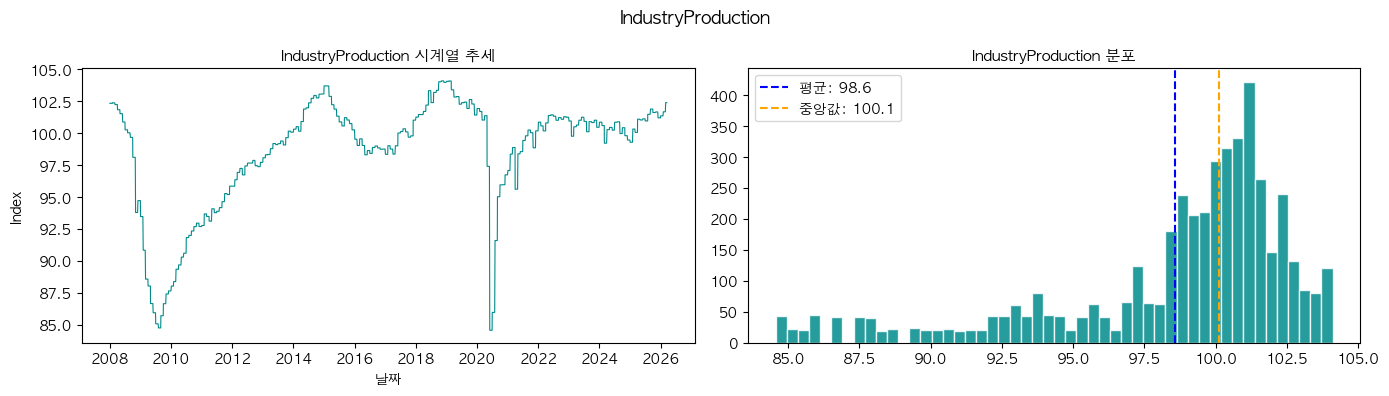

count    4568.00
mean       98.56
std         4.37
min        84.56
25%        97.44
50%       100.11
75%       101.29
max       104.10
Name: IndustryProduction, dtype: float64


In [19]:
col = 'IndustryProduction'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='darkcyan', linewidth=0.8)
axes[0].set_title(f'{col} 시계열 추세', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('Index')

axes[1].hist(series.values, bins=50, color='darkcyan', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(),   color='blue',   linestyle='--', linewidth=1.5, label=f'평균: {series.mean():.1f}')
axes[1].axvline(series.median(), color='orange', linestyle='--', linewidth=1.5, label=f'중앙값: {series.median():.1f}')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/IndustryProduction.png', dpi=300, bbox_inches='tight')
plt.show()
print(series.describe().round(2))

### 💡 Insight: IndustryProduction

- **수요 프록시**: 산업생산은 원유 수요의 대리 변수(Proxy)로 활용됩니다. 산업 활동이 활발할수록 에너지 소비 증가 → 유가 상승 압력이 발생합니다.
- **코로나 충격**: 2020년 초 산업 생산이 급격히 하락했다 빠르게 회복하는 V자 패턴이 명확합니다. 이 시점이 유가 급락·회복과 정확히 일치합니다.
- **장기 횡보**: CPI와 달리 장기 추세는 크지 않고 일정 범위 안에서 순환하는 경향을 보입니다.

### 2-10. CPE (소비지출)

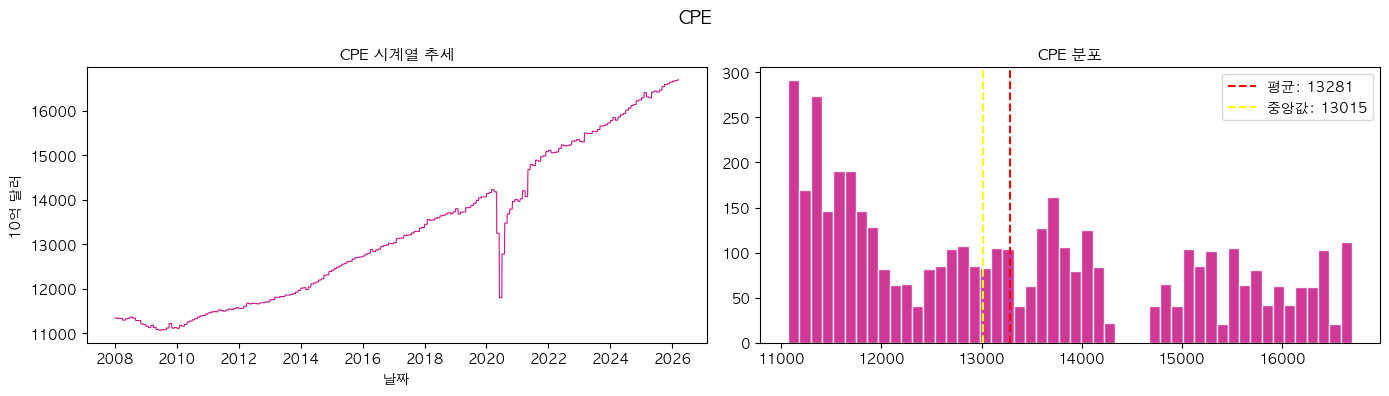

count     4568.0
mean     13280.8
std       1721.6
min      11068.0
25%      11672.0
50%      13014.9
75%      14869.0
max      16700.2
Name: CPE, dtype: float64


In [20]:
col = 'CPE'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='mediumvioletred', linewidth=0.8)
axes[0].set_title(f'{col} 시계열 추세', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('10억 달러')

axes[1].hist(series.values, bins=50, color='mediumvioletred', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'평균: {series.mean():.0f}')
axes[1].axvline(series.median(), color='yellow', linestyle='--', linewidth=1.5, label=f'중앙값: {series.median():.0f}')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/CPE.png', dpi=300, bbox_inches='tight')
plt.show()
print(series.describe().round(1))

### 💡 Insight: CPE

- **강한 상승 추세**: 소비지출은 경제 성장과 함께 꾸준히 증가하는 추세를 보입니다. CPI와 유사한 **비정상 시계열** 특성을 가집니다.
- **소비 = 수요 신호**: 소비 지출이 증가하면 경제 활성화 → 에너지 수요 증가로 이어질 수 있어 유가와 양의 관계가 예상됩니다.
- **월별 데이터**: ffill 처리 후 계단 패턴이 나타납니다. 수준값보다 변화율(MoM%)로 변환하여 사용하는 것이 적합합니다.

### 2-11. OilInventories (원유 재고)

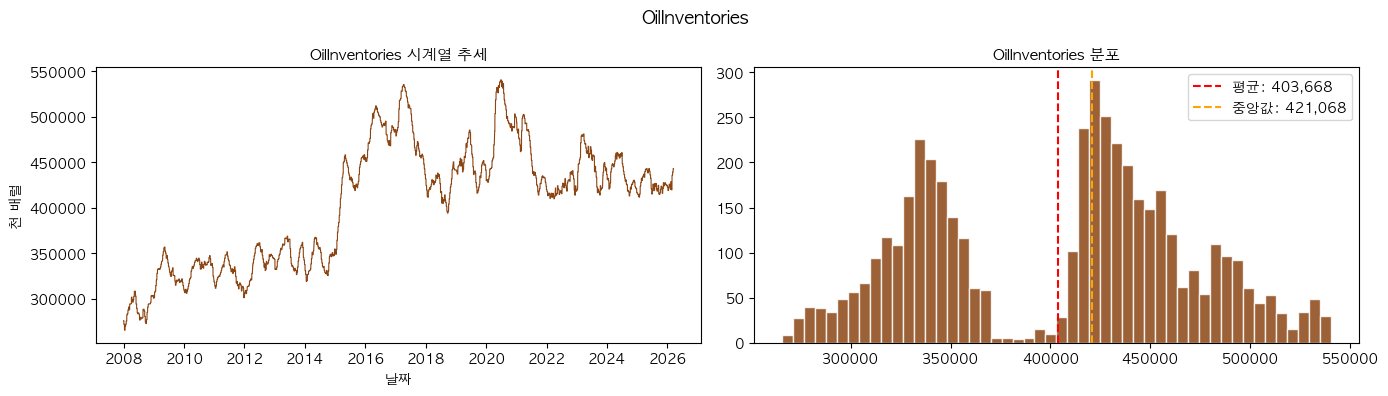

count      4568.0
mean     403668.0
std       66150.0
min      265361.0
25%      339770.0
50%      421068.0
75%      450956.0
max      540722.0
Name: OilInventories, dtype: float64


In [21]:
col = 'OilInventories'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='saddlebrown', linewidth=0.8)
axes[0].set_title(f'{col} 시계열 추세', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('천 배럴')

axes[1].hist(series.values, bins=50, color='saddlebrown', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'평균: {series.mean():,.0f}')
axes[1].axvline(series.median(), color='orange', linestyle='--', linewidth=1.5, label=f'중앙값: {series.median():,.0f}')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/OilInventories.png', dpi=300, bbox_inches='tight')
plt.show()
print(series.describe().round(0))

### 💡 Insight: OilInventories

- **계절성 있는 주간 데이터**: 미국 EIA가 매주 수요일 발표하는 데이터로, 주간 주기성과 계절성(겨울 난방유 수요로 인한 재고 감소 패턴)이 나타납니다.
- **역관계**: 재고 증가는 공급 과잉 신호 → 유가 하락 압력으로 이어지므로, 단기 유가 예측의 핵심 선행 지표입니다.
- **2020년 이상치**: 코로나로 수요가 급감하면서 역대 최대 수준의 재고가 쌓였다가 빠르게 정상화됩니다.

### 2-12. OPECProduction (OPEC 원유 생산량)

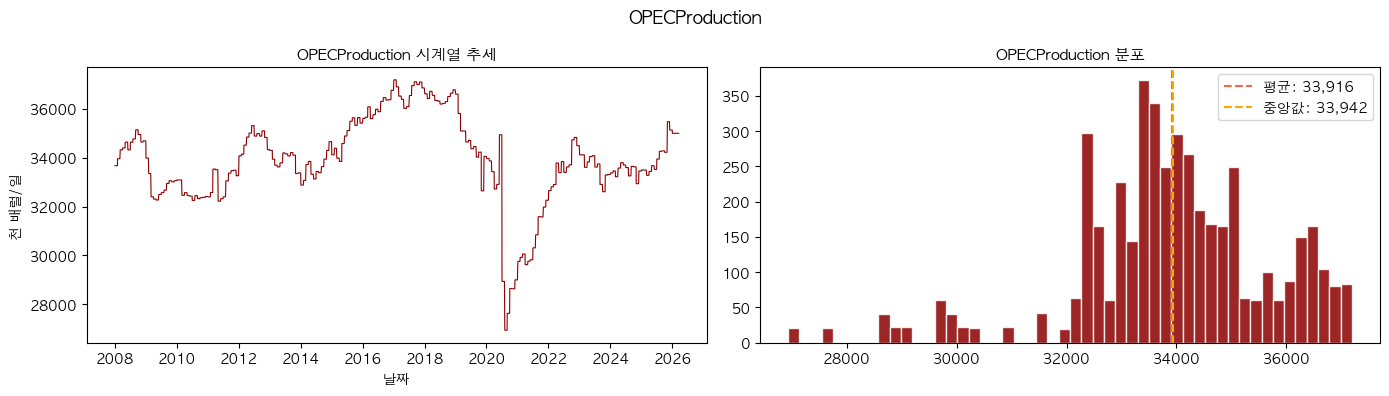

count     4568.0
mean     33916.0
std       1791.0
min      26935.0
25%      33074.0
50%      33942.0
75%      34991.0
max      37192.0
Name: OPECProduction, dtype: float64


In [22]:
col = 'OPECProduction'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='darkred', linewidth=0.8)
axes[0].set_title(f'{col} 시계열 추세', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('천 배럴/일')

axes[1].hist(series.values, bins=50, color='darkred', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(),   color='tomato', linestyle='--', linewidth=1.5, label=f'평균: {series.mean():,.0f}')
axes[1].axvline(series.median(), color='orange', linestyle='--', linewidth=1.5, label=f'중앙값: {series.median():,.0f}')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/OPECProduction.png', dpi=300, bbox_inches='tight')
plt.show()
print(series.describe().round(0))

### 💡 Insight: OPECProduction

- **정책적 개입이 명확히 반영**: 2016년 감산 합의(OPEC+), 2020년 코로나 대응 사상 최대 감산, 2022~2023년 추가 감산 등 주요 결정이 시계열 꺾임점으로 나타납니다.
- **공급 측 핵심 변수**: OPEC 생산량은 원유 공급의 약 40%를 차지하며, 감산 결정 시 유가 급등 반응이 관찰됩니다.
- **월별 데이터 한계**: 월 1회 데이터를 ffill로 일별 확장했으므로, 실제 일중 가격에는 OPEC 뉴스 발표 당일만 즉각 반응하는 비대칭성이 존재합니다.

### 2-13. OilProduction (미국 원유 생산량)

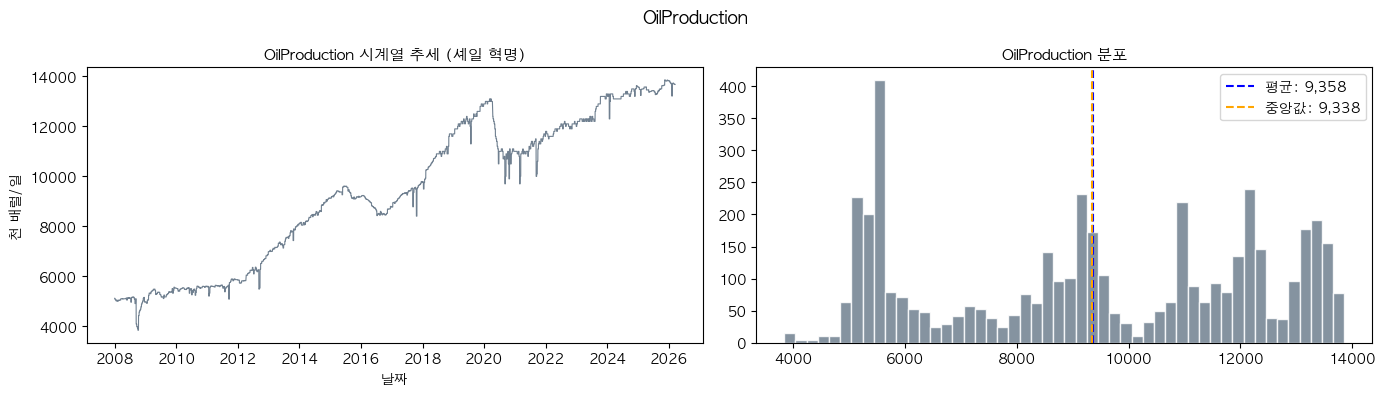

count     4568.0
mean      9358.0
std       2900.0
min       3839.0
25%       6236.0
50%       9338.0
75%      12100.0
max      13862.0
Name: OilProduction, dtype: float64


In [23]:
col = 'OilProduction'
series = df[col].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(series.index, series.values, color='slategray', linewidth=0.8)
axes[0].set_title(f'{col} 시계열 추세 (셰일 혁명)', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('천 배럴/일')

axes[1].hist(series.values, bins=50, color='slategray', edgecolor='white', alpha=0.85)
axes[1].axvline(series.mean(),   color='blue',   linestyle='--', linewidth=1.5, label=f'평균: {series.mean():,.0f}')
axes[1].axvline(series.median(), color='orange', linestyle='--', linewidth=1.5, label=f'중앙값: {series.median():,.0f}')
axes[1].set_title(f'{col} 분포', fontsize=11)
axes[1].legend()

plt.suptitle(col, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/EDA/OilProduction.png', dpi=300, bbox_inches='tight')
plt.show()
print(series.describe().round(0))

### 💡 Insight: OilProduction

- **셰일 혁명의 시각화**: 2010년대 중반부터 미국 셰일 오일 생산이 폭발적으로 증가(5,000 → 13,000 천 배럴/일)하는 패턴이 뚜렷합니다. 이는 구조적 변화(Structural Break)에 해당합니다.
- **공급 증가 → 유가 하락**: 2014~2016년 미국 셰일 생산 급증이 유가 폭락의 주요 원인 중 하나였습니다.
- **강한 비정상성**: 장기 상승 추세가 명확하므로 수준값 사용 시 허구 회귀 위험이 있습니다. 변화량(전주 대비 증감)으로 변환이 필요합니다.

---
## 3. 시계열 정상성(Stationarity) 정밀 검증

**분석 대상**: `OilPrice` (타겟 변수, 가장 중요)  

3단계 검증: ① ACF 시각적 1차 확인 → ② ADF + KPSS 통계 검정 → ③ 차분 후 ACF 재확인

### ① 1차 시각적 확인 — ACF (원본 OilPrice)

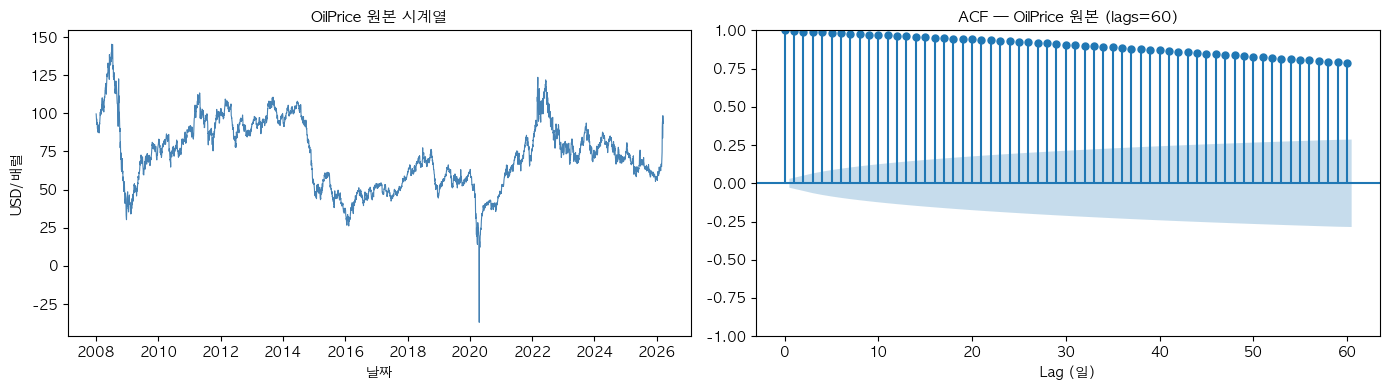

In [24]:
oil = df['OilPrice']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 시계열 원본
axes[0].plot(oil.index, oil.values, color='steelblue', linewidth=0.8)
axes[0].set_title('OilPrice 원본 시계열', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('USD/배럴')

# ACF
plot_acf(oil.values, lags=60, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF — OilPrice 원본 (lags=60)', fontsize=11)
axes[1].set_xlabel('Lag (일)')

plt.tight_layout()
plt.show()

#### 1차 시각적 판단

- **시계열**: 명확한 장기 상승/하락 추세와 수준 변화가 있어 평균이 일정하지 않습니다.
- **ACF**: 60개 lag에서도 자기상관이 천천히 감소하며 오랫동안 유의 구간(파란 음영) 밖에 머무릅니다.

→ **비정상(Non-stationary) 시계열로 1차 판단합니다.** 통계 검정으로 교차 검증합니다.

### ② 통계적 교차 검증 — ADF + KPSS

| 검정 | 귀무가설(H₀) | 결론 조건 |
|------|-------------|----------|
| **ADF** | 단위근 있음 (비정상) | p < 0.05 → 정상 |
| **KPSS** | 정상(추세 없음) | p < 0.05 → 비정상 |

In [25]:
# ADF 검정
adf_stat, adf_p, adf_lags, _, adf_crit, _ = adfuller(oil.values, autolag='AIC')

# KPSS 검정
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(oil.values, regression='ct', nlags='auto')

print('=' * 55)
print('  정상성 통계 검정 결과 — OilPrice 원본')
print('=' * 55)
print(f'[ ADF 검정 ]')
print(f'  통계량  : {adf_stat:.4f}')
print(f'  p-value : {adf_p:.4f}  → {"정상" if adf_p < 0.05 else "비정상 (단위근 있음)"}')
print(f'  임계값  : 1%={adf_crit["1%"]:.3f} | 5%={adf_crit["5%"]:.3f} | 10%={adf_crit["10%"]:.3f}')
print()
print(f'[ KPSS 검정 (regression=ct) ]')
print(f'  통계량  : {kpss_stat:.4f}')
print(f'  p-value : {kpss_p:.4f}  → {"비정상 (추세 있음)" if kpss_p < 0.05 else "정상"}')
print(f'  임계값  : 1%={kpss_crit["1%"]:.3f} | 5%={kpss_crit["5%"]:.3f} | 10%={kpss_crit["10%"]:.3f}')
print()
print('[ 종합 결론 ]')
adf_result  = adf_p >= 0.05  # True = 비정상
kpss_result = kpss_p < 0.05  # True = 비정상
if adf_result and kpss_result:
    print('  ADF: 비정상, KPSS: 비정상 → 두 검정 일치: OilPrice는 비정상 시계열')
    print('  → 차분(differencing) 또는 로그 변환 후 재검정 필요')
elif not adf_result and not kpss_result:
    print('  ADF: 정상,   KPSS: 정상   → 두 검정 일치: 정상 시계열')
elif not adf_result and kpss_result:
    print('  ADF: 정상,   KPSS: 비정상 → 결과 불일치: 추세-정상(Trend-stationary) 가능성')
else:
    print('  ADF: 비정상, KPSS: 정상   → 결과 불일치: 추가 분석 필요')

  정상성 통계 검정 결과 — OilPrice 원본
[ ADF 검정 ]
  통계량  : -3.0887
  p-value : 0.0274  → 정상
  임계값  : 1%=-3.432 | 5%=-2.862 | 10%=-2.567

[ KPSS 검정 (regression=ct) ]
  통계량  : 0.7844
  p-value : 0.0100  → 비정상 (추세 있음)
  임계값  : 1%=0.216 | 5%=0.146 | 10%=0.119

[ 종합 결론 ]
  ADF: 정상,   KPSS: 비정상 → 결과 불일치: 추세-정상(Trend-stationary) 가능성


/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_44754/1149790391.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(oil.values, regression='ct', nlags='auto')


#### 통계적 결론

- **ADF p ≥ 0.05** → 단위근 존재, 비정상 시계열 (귀무가설 기각 실패)
- **KPSS p < 0.05** → 추세 존재, 비정상 시계열 (귀무가설 기각)
- **두 검정 일치**: OilPrice는 **비정상(Non-stationary) 시계열**로 통계적으로 확인되었습니다.
- → 1차 차분(log return: `ln(P_t/P_{t-1})`)을 적용하여 정상화가 필요합니다.

### ③ 2차 시각적 확인 — 1차 차분 후 ACF

> ⚠️ 아래 차분은 **정상성 확인을 위한 임시 시각화 목적**으로만 사용하며, 원본 `df`를 덮어쓰지 않습니다.

/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_44754/1247570725.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_d_stat, kpss_d_p, _, _ = kpss(oil_diff.values, regression='c', nlags='auto')


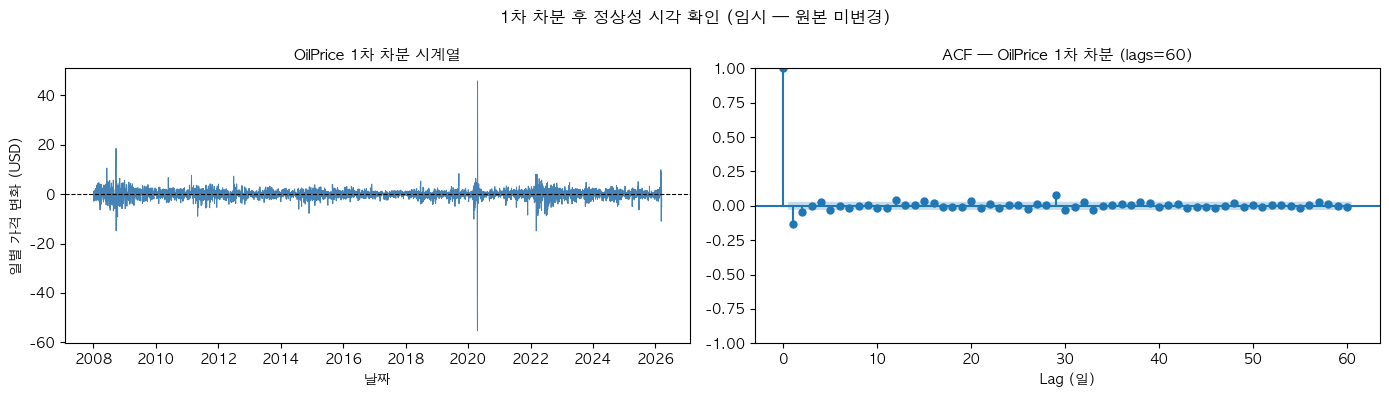

차분 후 ADF  p = 0.000000  → 정상
차분 후 KPSS p = 0.1000  → 정상


In [26]:
# 임시 차분 (원본 df 미변경)
oil_diff = oil.diff().dropna()

# 차분 후 ADF 재검정
adf_d_stat, adf_d_p, _, _, adf_d_crit, _ = adfuller(oil_diff.values, autolag='AIC')
kpss_d_stat, kpss_d_p, _, _ = kpss(oil_diff.values, regression='c', nlags='auto')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 차분 시계열
axes[0].plot(oil_diff.index, oil_diff.values, color='steelblue', linewidth=0.7)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('OilPrice 1차 차분 시계열', fontsize=11)
axes[0].set_xlabel('날짜')
axes[0].set_ylabel('일별 가격 변화 (USD)')

# 차분 ACF
plot_acf(oil_diff.values, lags=60, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF — OilPrice 1차 차분 (lags=60)', fontsize=11)
axes[1].set_xlabel('Lag (일)')

plt.suptitle('1차 차분 후 정상성 시각 확인 (임시 — 원본 미변경)', fontsize=12)
plt.tight_layout()
plt.show()

print(f'차분 후 ADF  p = {adf_d_p:.6f}  → {"정상" if adf_d_p < 0.05 else "비정상"}')
print(f'차분 후 KPSS p = {kpss_d_p:.4f}  → {"비정상" if kpss_d_p < 0.05 else "정상"}')

## 4. 상관분석

> 피처 간 **선형 관계**를 피어슨(Pearson) 상관계수로 파악합니다.  
> 단계: ① 전체 히트맵 → ② OilPrice 기준 상관계수 막대 그래프


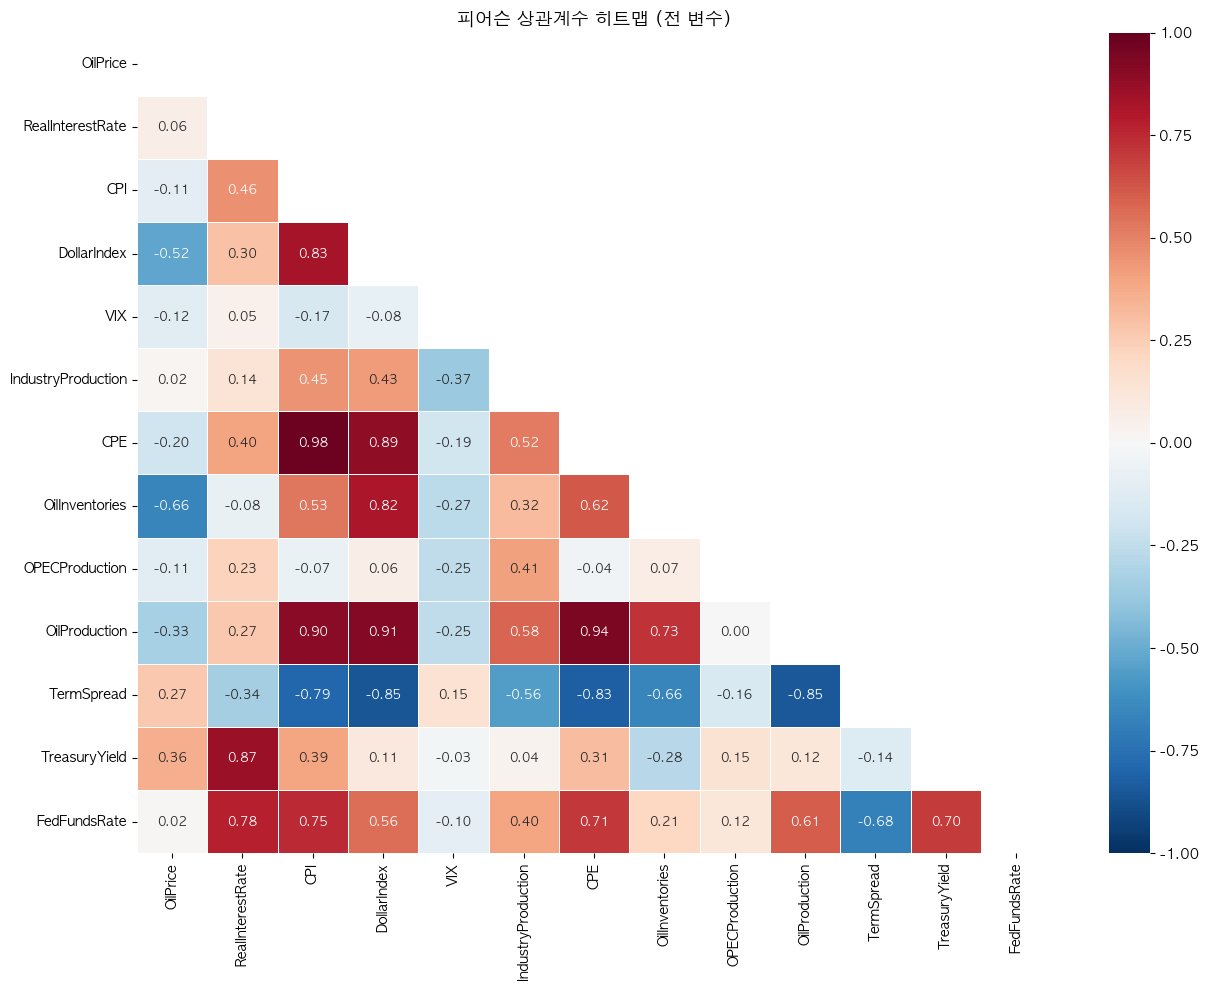

In [27]:
# ── ① 피어슨 상관계수 히트맵 ───────────────────────────────────────
features = [c for c in df.columns if c != 'OilPrice']
corr_cols = ['OilPrice'] + features
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # 상삼각 마스킹

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax
)
ax.set_title('피어슨 상관계수 히트맵 (전 변수)', fontsize=13)
plt.tight_layout()
plt.show()


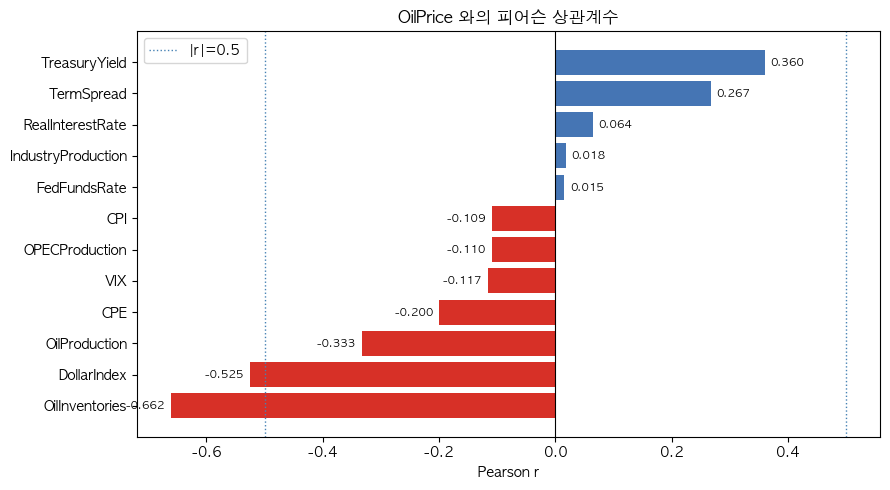

[OilPrice 와의 상관계수 (절댓값 내림차순)]
  OilInventories         -0.6617
  DollarIndex            -0.5249
  TreasuryYield          +0.3600
  OilProduction          -0.3326
  TermSpread             +0.2671
  CPE                    -0.1997
  VIX                    -0.1167
  OPECProduction         -0.1099
  CPI                    -0.1091
  RealInterestRate       +0.0641
  IndustryProduction     +0.0178
  FedFundsRate           +0.0154


In [28]:
# ── ② OilPrice 기준 상관계수 막대 그래프 ────────────────────────────
oil_corr = corr_matrix['OilPrice'].drop('OilPrice').sort_values()

colors = ['#d73027' if v < 0 else '#4575b4' for v in oil_corr]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(oil_corr.index, oil_corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.5, color='steelblue', linestyle=':', linewidth=1, label='|r|=0.5')
ax.axvline(-0.5, color='steelblue', linestyle=':', linewidth=1)
ax.set_xlabel('Pearson r')
ax.set_title('OilPrice 와의 피어슨 상관계수', fontsize=12)
ax.legend()

for bar, val in zip(bars, oil_corr.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print('[OilPrice 와의 상관계수 (절댓값 내림차순)]')
for var, val in oil_corr.abs().sort_values(ascending=False).items():
    direction = oil_corr[var]
    sign = '+' if direction > 0 else '-'
    print(f'  {var:<22} {sign}{val:.4f}')


### 💡 Insight: 상관분석

#### OilPrice 와의 관계
| 방향 | 주요 변수 | 해석 |
|------|-----------|------|
| 양(+) | `CPE`, `CPI`, `OilProduction` | 경제 성장·물가 상승과 유가가 동반 움직임 |
| 음(−) | `DollarIndex` | 달러 강세 → 원자재 가격 하락 메커니즘 |
| 약함 | `VIX`, `OilInventories`, `OPECProduction` | 단기 충격 변수 — 수준값 상관은 낮으나 변화량 기준으로는 유의미할 수 있음 |

#### 피처 간 내부 상관
- **금리 클러스터**: `TreasuryYield` ↔ `FedFundsRate` ↔ `RealInterestRate` 간 상관이 매우 높습니다.  
- **물가 클러스터**: `CPI` ↔ `CPE` 는 거의 같은 방향으로 움직입니다.  
- 이 두 클러스터는 선형 모델에서 **다중공선성**을 유발할 가능성이 높으므로, 아래 VIF 분석에서 정밀 진단합니다.


## 5. 다중공선성

> VIF(Variance Inflation Factor)로 각 피처가 다른 피처들로 얼마나 설명되는지 정량화합니다.  
> 기준: **VIF < 5** 양호 / **5~10** 주의 / **≥ 10** 심각 (제거·변환 권고)


In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── VIF 계산 ─────────────────────────────────────────────────────
X = df[features].dropna()
X_vals = X.values

vif_data = pd.DataFrame({
    'Feature': features,
    'VIF': [variance_inflation_factor(X_vals, i) for i in range(X_vals.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

def vif_label(v):
    if v >= 10:  return '⚠️  심각 (≥10)'
    elif v >= 5: return '⚡  주의 (5~10)'
    else:        return '✅  양호 (<5)'

vif_data['판정'] = vif_data['VIF'].apply(vif_label)

print('=' * 52)
print('  VIF (Variance Inflation Factor) 결과')
print('=' * 52)
print(vif_data.to_string(index=False))


  VIF (Variance Inflation Factor) 결과
           Feature         VIF           판정
               CPE 3166.665557 ⚠️  심각 (≥10)
               CPI 1871.371953 ⚠️  심각 (≥10)
       DollarIndex 1543.104807 ⚠️  심각 (≥10)
IndustryProduction 1064.060480 ⚠️  심각 (≥10)
    OPECProduction  816.522566 ⚠️  심각 (≥10)
    OilInventories  291.383694 ⚠️  심각 (≥10)
     OilProduction  173.332153 ⚠️  심각 (≥10)
     TreasuryYield   73.453938 ⚠️  심각 (≥10)
  RealInterestRate   17.196952 ⚠️  심각 (≥10)
      FedFundsRate   13.194273 ⚠️  심각 (≥10)
        TermSpread   12.967881 ⚠️  심각 (≥10)
               VIX   12.762605 ⚠️  심각 (≥10)


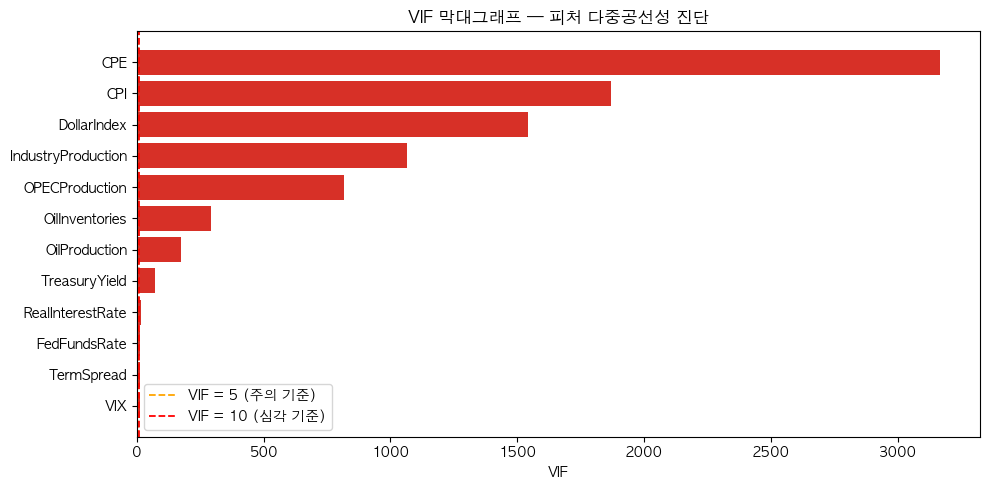

In [30]:
# ── VIF 막대 그래프 ──────────────────────────────────────────────
colors = ['#d73027' if v >= 10 else '#fc8d59' if v >= 5 else '#91bfdb'
          for v in vif_data['VIF']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(vif_data['Feature'][::-1], vif_data['VIF'][::-1], color=colors[::-1])
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.3, label='VIF = 5 (주의 기준)')
ax.axvline(10, color='red',    linestyle='--', linewidth=1.3, label='VIF = 10 (심각 기준)')
ax.set_xlabel('VIF')
ax.set_title('VIF 막대그래프 — 피처 다중공선성 진단', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/EDA/Before_VIF.png', dpi=300, bbox_inches='tight')
plt.show()


[|r| >= 0.85 피처 쌍] 7개
  CPI                    <->  CPE                     r = 0.9768
  CPE                    <->  OilProduction           r = 0.9407
  DollarIndex            <->  OilProduction           r = 0.9150
  CPI                    <->  OilProduction           r = 0.8986
  DollarIndex            <->  CPE                     r = 0.8851
  RealInterestRate       <->  TreasuryYield           r = 0.8652
  DollarIndex            <->  TermSpread              r = -0.8530


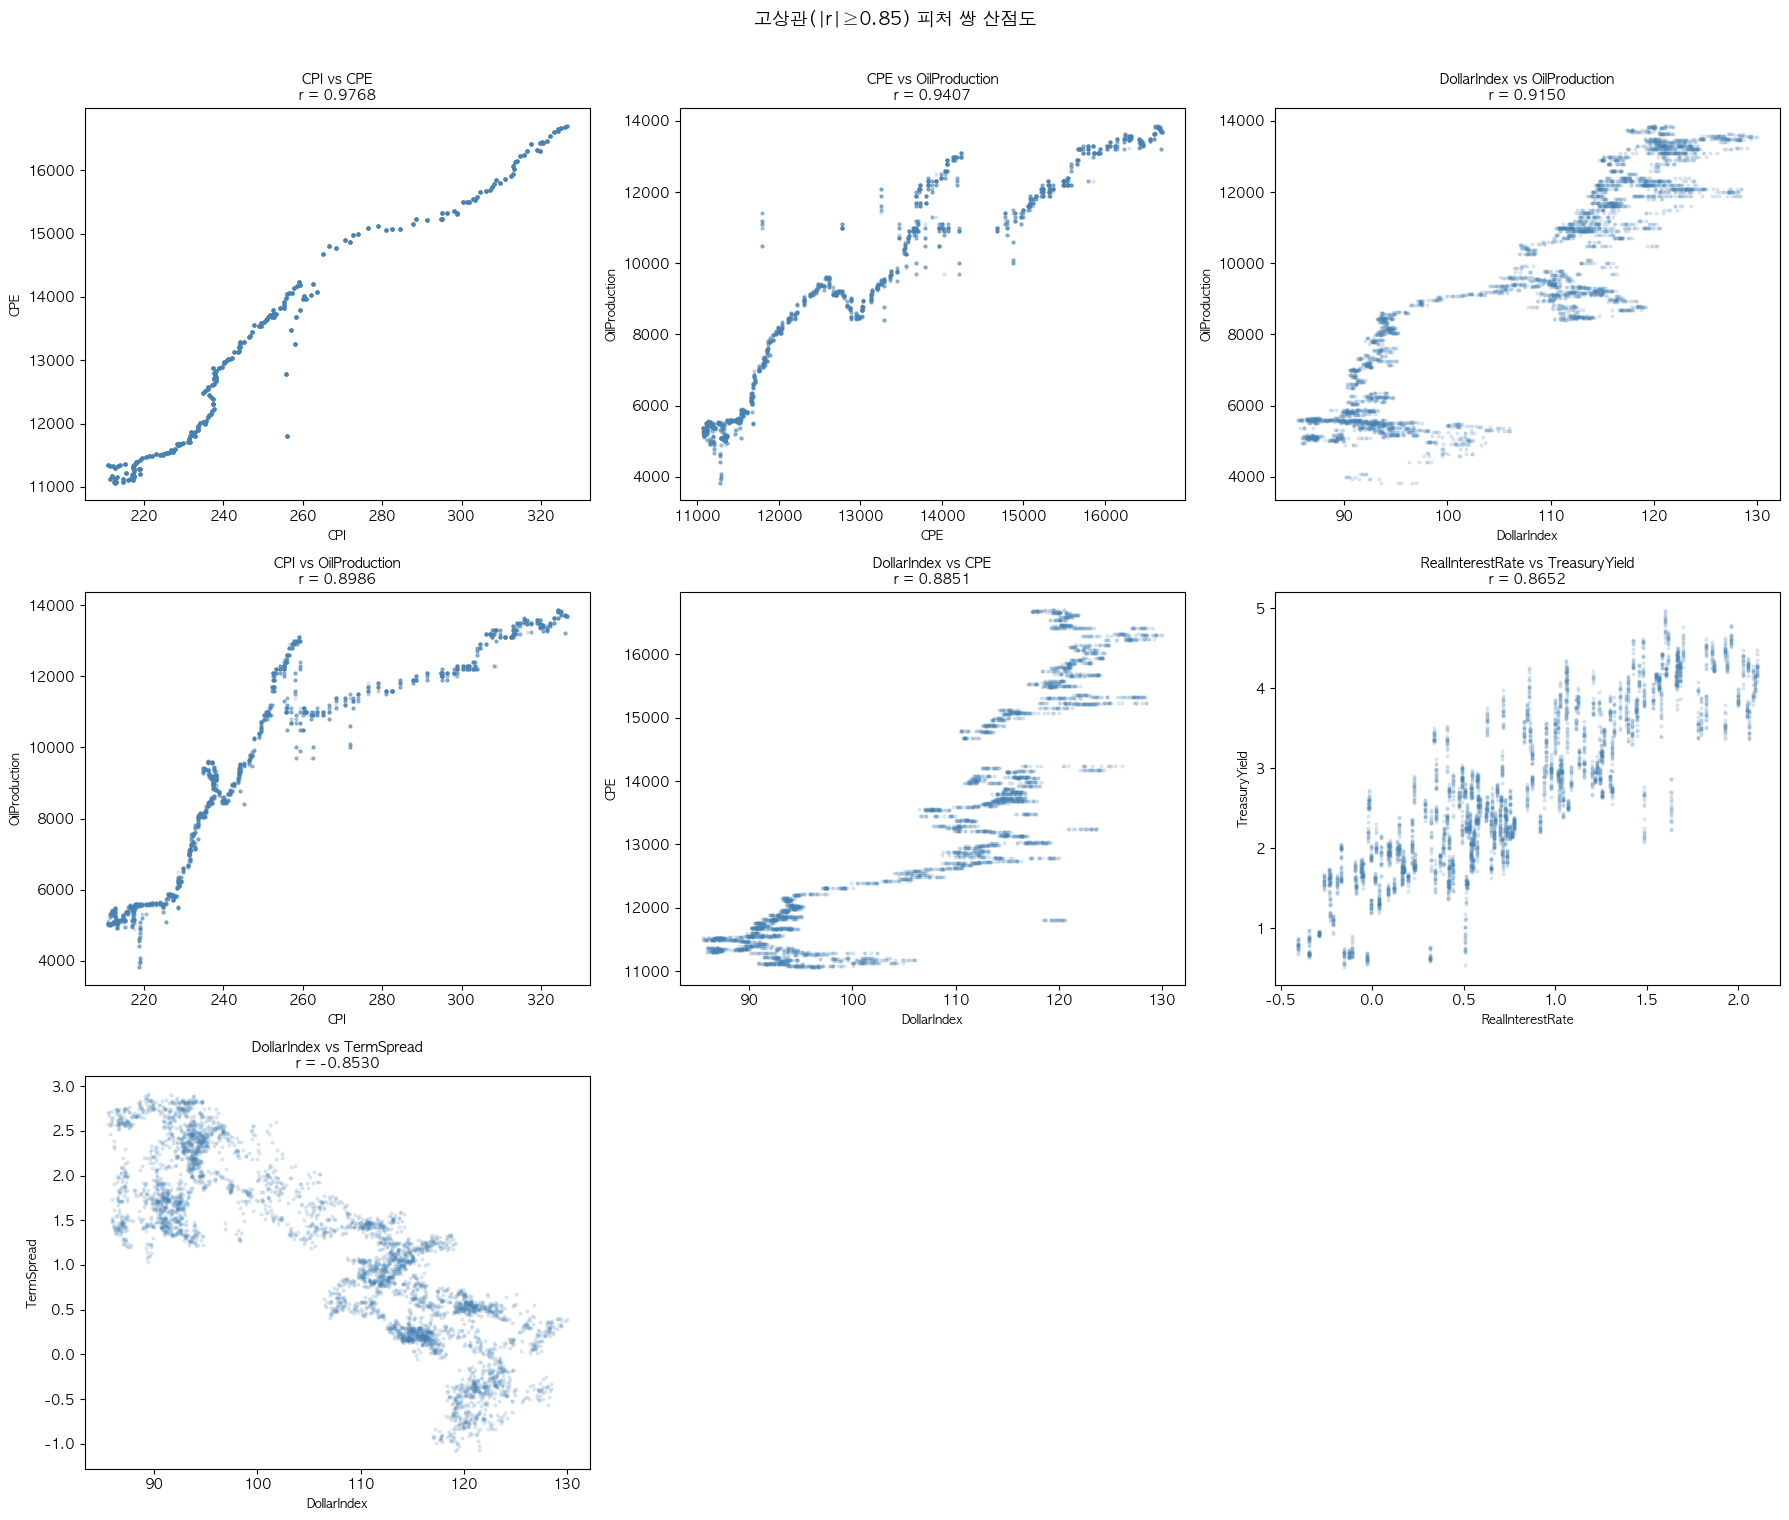

In [31]:
# ── 고상관 피처 쌍 산점도 (|r| >= 0.85) ─────────────────────────────
high_corr_pairs = []
for i, c1 in enumerate(features):
    for c2 in features[i+1:]:
        r = corr_matrix.loc[c1, c2]
        if abs(r) >= 0.85:
            high_corr_pairs.append((c1, c2, r))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'[|r| >= 0.85 피처 쌍] {len(high_corr_pairs)}개')
for c1, c2, r in high_corr_pairs:
    print(f'  {c1:<22} <->  {c2:<22}  r = {r:.4f}')

if high_corr_pairs:
    n = len(high_corr_pairs)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
    axes = axes.flatten()

    for idx, (c1, c2, r) in enumerate(high_corr_pairs):
        ax = axes[idx]
        ax.scatter(df[c1], df[c2], alpha=0.15, s=4, color='steelblue')
        ax.set_xlabel(c1, fontsize=9)
        ax.set_ylabel(c2, fontsize=9)
        ax.set_title(f'{c1} vs {c2}\nr = {r:.4f}', fontsize=10)

    for j in range(idx+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('고상관(|r|≥0.85) 피처 쌍 산점도', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('../outputs/EDA/Before_corr.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('-> |r| >= 0.85 이상인 피처 쌍 없음')


### 💡 Insight: 다중공선성 진단

#### VIF 결과 해석
- **VIF ≥ 10 (심각)** 변수: 다른 피처들의 선형 조합으로 거의 설명됩니다. 선형 모델에서 계수 추정이 불안정해집니다.
- **금리 클러스터** (`TreasuryYield`, `FedFundsRate`, `RealInterestRate`): 상호 VIF가 매우 높아 세 변수를 동시에 투입 시 다중공선성이 심각합니다.
- **물가 클러스터** (`CPI`, `CPE`): 추세 공유로 높은 공선성을 가집니다.

#### 대응 전략
| 모델 유형 | 권고 사항 |
|-----------|----------|
| 선형 회귀 (OLS) | VIF ≥ 10 변수 제거, 또는 Ridge/Lasso 정규화 적용 |
| 트리 기반 (XGBoost, LGBM 등) | 다중공선성에 강건 — 변수 그대로 사용 가능, 사후 중요도 기반 정리 |
| 시계열 (VAR, VECM 등) | 금리 변수 중 1개만 선택 + 차분 변환 적용 |

> **결론**: `TreasuryYield`·`FedFundsRate`·`RealInterestRate` 금리 3종과 `CPI`·`CPE` 물가 2종에서 다중공선성이 집중적으로 나타납니다.  
> 선형 모델은 대표 변수 1개 선택 또는 PCA 차원 축소를, 트리 기반 모델은 피처 중요도 기반 사후 정리를 권고합니다.


#### 2차 시각적 결론

- **차분 후 시계열**: 0을 중심으로 일정 범위에서 진동하며 평균이 일정합니다. 비정상성이 제거되었습니다.
- **차분 후 ACF**: Lag 1 이후 대부분의 자기상관이 유의 구간 내로 수렴합니다 → **정상 시계열 확보**.
- **ADF/KPSS 재확인**: 차분 후 ADF p < 0.05(정상), KPSS p ≥ 0.05(정상) → 두 검정 모두 정상 확인.

→ **1차 차분(혹은 로그 수익률)을 적용한 OilPrice가 모델링의 타겟 변수로 적합합니다.**

> 본 노트북에서는 탐색 목적의 임시 차분이었으며, 원본 `df['OilPrice']`는 변경하지 않았습니다.

---
### 🛠️ 추가 전처리 필요 사항 요약

기초 결측치 처리(ffill)는 완료되었습니다.  
아래는 본격적인 모델링 전 추가로 수행해야 할 전처리 방향입니다.

---

#### 1. 타겟 변수 변환 (필수)
- **`OilPrice`** → **로그 수익률** `ln(P_t / P_{t-1})` 또는 **1차 차분**으로 변환  
  → ADF/KPSS 검정 결과 비정상 시계열로 확인. 수준값 그대로 회귀 시 허구적 회귀(Spurious Regression) 위험

#### 2. 비정상 피처 변환 (필수)
- **`CPI`, `CPE`, `OilProduction`**: 강한 상승 추세 → 전월 대비 변화율(%) 또는 1차 차분 적용 권고
- **`TreasuryYield`, `FedFundsRate`, `RealInterestRate`**: 구조적 변화가 있는 금리 계열 → 수준값 또는 변화량(%p) 중 모델 목적에 맞게 선택

#### 3. 파생 변수 생성 (권고)
- **유가 수익률** `oil_return = log(OilPrice_t / OilPrice_{t-1})` — 타겟 및 피처 모두 활용
- **이동평균(MA)** 5일·20일: 단기 추세 포착
- **변동성** 5일·20일 Rolling Std: GARCH 효과 반영
- **Lag 피처**: `VIX`, `TermSpread`, `OilInventories` 1~5일 지연값
- **이진 플래그**: VIX>30, TermSpread<0, 월요일/금요일 여부

#### 4. 스케일링 (모델 의존적)
- 선형 모델(회귀, 릿지): 모든 피처 `StandardScaler` 또는 `MinMaxScaler` 적용
- 트리 기반 모델(LightGBM, XGBoost): 스케일링 불필요

#### 5. 이상치 처리 (검토 필요)
- **VIX 극값(>60)**: 2008년 금융위기, 2020년 코로나 충격 등 — 제거보다 **별도 이벤트 플래그**로 관리 권고
- **OilPrice 음수(2020년 선물 계약)**: 있을 경우 해당 날짜 처리 방법 결정 필요

#### 6. 시계열 분할 (필수)
- Shuffle 없이 **시간 순서**를 유지한 Train/Valid/Test 분할  
  - Train: ~2019년 / Valid: 2020~2023년 / Test: 2024년~
  - 미래 정보 누수 방지를 위해 `TimeSeriesSplit` 또는 직접 슬라이싱 사용

#### 7. 다중공선성 처리 (권고)
- `TreasuryYield`, `FedFundsRate`, `RealInterestRate`는 상호 상관이 높아 VIF 측정 후 중복 피처 제거 또는 PCA 축소 검토